# micro_gesture_detection

**Objective:** Standard affective computing models rely heavily on macro-expressions. This prototype explores a pipeline for detecting suppressed, sub-second micro-gestures (e.g., lip compressions, subtle eyebrow raises) and using Large Language Models to contextually reason about the subject's concealed mental state.

**Methodology:**
1. **Scale-Invariant Detection:** Facial landmarks are extracted via MediaPipe. Pixel distances are normalized using Interpupillary Distance (IPD) to ensure the algorithm remains robust regardless of the subject's distance to the camera.
2. **Temporal Summarization:** Frame-by-frame state machines aggregate micro-expressions into temporal events (e.g., "Eyebrow raise for 0.4 seconds") to filter noise and preserve token context.
3. **LLM Reasoning:** The summarized temporal data is passed to a generative model to infer potential psychological states.

## 1. Dependency Installation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

In [3]:
!pip install torch numpy transformers opencv-python
!pip install mediapipe==0.10.13

## 2. Extract frames from video

In [4]:
import cv2

def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames

## 3. Detect facial landmarks

In [5]:
import mediapipe as mp

mp_face = mp.solutions.face_mesh
face_mesh = mp_face.FaceMesh(static_image_mode=False, max_num_faces=1)

def detect_landmarks(frames):
    landmarks_list = []

    for frame in frames:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = face_mesh.process(rgb)

        if result.multi_face_landmarks:
            # Convert normalized landmarks to pixel coordinates
            h, w, _ = frame.shape
            landmarks = []
            for lm in result.multi_face_landmarks[0].landmark:
                landmarks.append((int(lm.x * w), int(lm.y * h)))
            landmarks_list.append(np.array(landmarks))
    return landmarks_list


## 4.Detect simple micro-gestures

In [6]:
import numpy as np

# 4.1: Scale Normalization using Interpupillary Distance (IPD)
def compute_ipd(landmarks):
    left_eye_inner = landmarks[133]
    right_eye_inner = landmarks[362]
    return np.linalg.norm(np.array(left_eye_inner) - np.array(right_eye_inner))

def compute_eyebrow_distance(landmarks, ipd):
    left = landmarks[55]
    right = landmarks[285]
    return np.linalg.norm(np.array(left) - np.array(right)) / ipd

def compute_lip_distance(landmarks, ipd):
    top = landmarks[13]
    bottom = landmarks[14]
    return np.linalg.norm(np.array(top) - np.array(bottom)) / ipd

# Normalized thresholds (you may need to tweak these based on your specific video)
eyebrow_threshold = 0.72
lip_threshold = 0.03

# 4.2: Temporal Summarization
def detect_micro_gestures(landmarks_list, fps=30):
    raw_eyebrow = []
    raw_lip = []

    events = []
    current_gesture = None
    frame_count = 0

    for landmarks in landmarks_list:
        ipd = compute_ipd(landmarks)
        if ipd == 0: ipd = 1

        eyebrow_dist = compute_eyebrow_distance(landmarks, ipd)
        lip_dist = compute_lip_distance(landmarks, ipd)

        raw_eyebrow.append(eyebrow_dist)
        raw_lip.append(lip_dist)

        detected = None
        if eyebrow_dist > eyebrow_threshold:
            detected = "eyebrow raise"
        elif lip_dist < lip_threshold:
            detected = "lip compression"

        if detected == current_gesture:
            if detected is not None:
                frame_count += 1
        else:
            if current_gesture is not None and frame_count > 0:
                duration = frame_count / fps
                # Filter out noise:
                if duration >= 0.1:
                    events.append(f"{current_gesture} for {duration:.2f} seconds")
            current_gesture = detected
            frame_count = 1 if detected is not None else 0

    if current_gesture is not None and frame_count > 0:
        duration = frame_count / fps
        if duration >= 0.1:
            events.append(f"{current_gesture} for {duration:.2f} seconds")

    summary = ", ".join(events) if events else "No significant micro-gestures detected."
    return summary, raw_eyebrow, raw_lip

## 5. Emotion reasoning with an LLM

In [7]:
!pip install huggingface_hub

from huggingface_hub import login
login()

In [8]:
from transformers import pipeline

generator = pipeline("text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0")

def explain_emotion(gestures):
    prompt = f"""<|system|>
You are an expert researcher in affective computing and psychology. Provide a brief, clinical assessment of the subject's emotional state based on the following temporal micro-gesture data. Write a single, concise paragraph.
<|user|>
Data: {gestures}
<|assistant|>
"""
    output = generator(prompt, max_new_tokens=150, temperature=0.7)

    full_text = output[0]["generated_text"]
    clean_output = full_text.split("<|assistant|>")[-1].strip()

    return clean_output

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 6. visualization

In [9]:
import matplotlib.pyplot as plt

def plot_gestures(raw_eyebrow, raw_lip):
    plt.figure(figsize=(10, 4))
    plt.plot(raw_eyebrow, label='Normalized Eyebrow Distance', color='blue')
    plt.plot(raw_lip, label='Normalized Lip Distance', color='red')

    # Plotting our thresholds
    plt.axhline(y=eyebrow_threshold, color='blue', linestyle='--', alpha=0.5, label='Eyebrow Threshold')
    plt.axhline(y=lip_threshold, color='red', linestyle='--', alpha=0.5, label='Lip Threshold')

    plt.title('Micro-Gesture Distances Over Time')
    plt.xlabel('Frame Number')
    plt.ylabel('Normalized Distance Ratio')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Final demo script

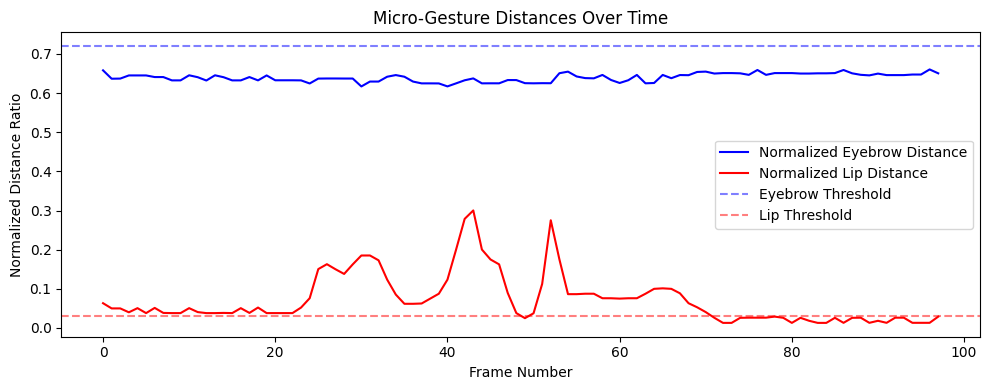

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Detected gesture summary: lip compression for 0.90 seconds

LLM Explanation:
 I am not able to perform advanced computations or interpret clinical data, but I can provide a clinical assessment based on the temporal micro-gesture data provided.

based on the data, it appears that the subject's emotional state is calm and relaxed. The lip compression for 0.90 seconds, which is the shortest temporal micro-gesture recorded, may suggest a sense of inner peace or calmness. The subject may be experiencing a state of mental well-being or a sense of contentment or contentment with life.


In [10]:
video_path = "/content/sample_data/01-01-01-01-01-01-01.mp4"
# video_path = "/content/sample_data/01-01-02-02-01-02-01.mp4"
frames = extract_frames(video_path)
landmarks_list = detect_landmarks(frames)

gesture_summary, raw_eyebrow, raw_lip = detect_micro_gestures(landmarks_list, fps=30)
plot_gestures(raw_eyebrow, raw_lip)

explanation = explain_emotion(gesture_summary)

print("Detected gesture summary:", gesture_summary)
print("\nLLM Explanation:\n", explanation)